In [6]:
from pathlib import Path
import numpy as np
import joblib
import json

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

processed_dir = PROJECT_ROOT / "processed"
artifacts_dir = PROJECT_ROOT / "artifacts"

print("Project root:", PROJECT_ROOT)
print("Processed exists:", processed_dir.exists())
print("Artifacts exists:", artifacts_dir.exists())

Project root: c:\Users\okani\OneDrive\Masaüstü\pycharm\exoplanet_intelligence
Processed exists: True
Artifacts exists: True


In [7]:
data = np.load(processed_dir / "exoplanet_splits_scaled.npz")

X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

label_encoder = joblib.load(artifacts_dir / "label_encoder.pkl")

with open(artifacts_dir / "feature_columns.json", "r", encoding="utf-8") as f:
    feature_cols = json.load(f)

with open(artifacts_dir / "class_names.json", "r", encoding="utf-8") as f:
    class_names = json.load(f)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)
print("Classes:", class_names)
print("Feature count:", len(feature_cols))

Train: (4270, 25)
Val: (915, 25)
Test: (915, 25)
Classes: ['Gas Giant', 'Mini-Neptune', 'Neptune-like', 'Sub-Earth', 'Super-Earth', 'Super-Jupiter']
Feature count: 25


c:\Users\okani\OneDrive\Masaüstü\pycharm\exoplanet_intelligence\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [8]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [9]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

X_train_tensor.shape, y_train_tensor.shape

(torch.Size([4270, 25]), torch.Size([4270]))

In [10]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cpu'

In [11]:
X_train_tensor = X_train_tensor.to(device)
X_val_tensor = X_val_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)

y_train_tensor = y_train_tensor.to(device)
y_val_tensor = y_val_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)


In [12]:
class ExoplanetClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        return self.model(x)    

In [13]:
input_dim = X_train_tensor.shape[1]
hidden_dim = 64
output_dim = len(class_names)

model = ExoplanetClassifier(
    input_dim = input_dim,
    hidden_dim = hidden_dim,
    output_dim = output_dim
).to(device)

model

ExoplanetClassifier(
  (model): Sequential(
    (0): Linear(in_features=25, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=6, bias=True)
  )
)

In [15]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [16]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = correct / len(y_true)
    return acc

In [17]:
torch.manual_seed(42)

epochs = 300

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(epochs):
    model.train()

    train_logits = model(X_train_tensor)

    train_loss = loss_fn(train_logits, y_train_tensor)

    train_preds = torch.argmax(train_logits, dim=1)
    train_acc = accuracy_fn(y_train_tensor, train_preds)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        val_logits = model(X_val_tensor)
        val_loss = loss_fn(val_logits, y_val_tensor)

        val_preds = torch.argmax(val_logits, dim=1)
        val_acc = accuracy_fn(y_val_tensor, val_preds)

    history["train_loss"].append(train_loss.item())
    history["val_loss"].append(val_loss.item())
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if epoch % 25 == 0:
        print(
            f"Epoch : {epoch:03d} | "
            f"Train Loss : {train_loss:.4f} | "
            f"Train Acc : {train_acc:.4f} | "
            f"Val Loss : {val_loss:.4f} | "
            f"Val Acc : {val_acc:.4f}"
        )    

Epoch : 000 | Train Loss : 1.7964 | Train Acc : 0.2066 | Val Loss : 1.7757 | Val Acc : 0.2142
Epoch : 025 | Train Loss : 1.3206 | Train Acc : 0.5864 | Val Loss : 1.3146 | Val Acc : 0.5858
Epoch : 050 | Train Loss : 0.9890 | Train Acc : 0.6499 | Val Loss : 0.9972 | Val Acc : 0.6393
Epoch : 075 | Train Loss : 0.7741 | Train Acc : 0.7201 | Val Loss : 0.7795 | Val Acc : 0.7290
Epoch : 100 | Train Loss : 0.6146 | Train Acc : 0.7775 | Val Loss : 0.6210 | Val Acc : 0.7760
Epoch : 125 | Train Loss : 0.4959 | Train Acc : 0.8302 | Val Loss : 0.5035 | Val Acc : 0.8328
Epoch : 150 | Train Loss : 0.4041 | Train Acc : 0.8721 | Val Loss : 0.4156 | Val Acc : 0.8732
Epoch : 175 | Train Loss : 0.3377 | Train Acc : 0.8998 | Val Loss : 0.3520 | Val Acc : 0.8929
Epoch : 200 | Train Loss : 0.2873 | Train Acc : 0.9129 | Val Loss : 0.3050 | Val Acc : 0.9027
Epoch : 225 | Train Loss : 0.2456 | Train Acc : 0.9227 | Val Loss : 0.2682 | Val Acc : 0.9093
Epoch : 250 | Train Loss : 0.2102 | Train Acc : 0.9344 | Val

In [18]:
print(f"Final Train Acc: {history['train_acc'][-1]:.4f}")
print(f"Final Val Acc: {history['val_acc'][-1]:.4f}")
print(f"Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Final Val Loss: {history['val_loss'][-1]:.4f}")

Final Train Acc: 0.9597
Final Val Acc: 0.9355
Final Train Loss: 0.1587
Final Val Loss: 0.1985


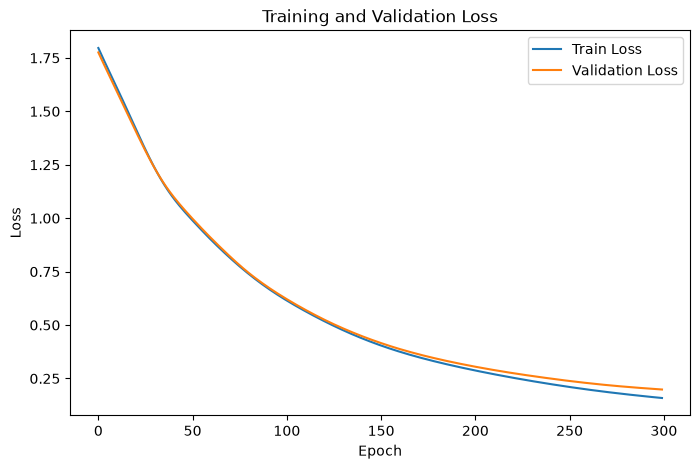

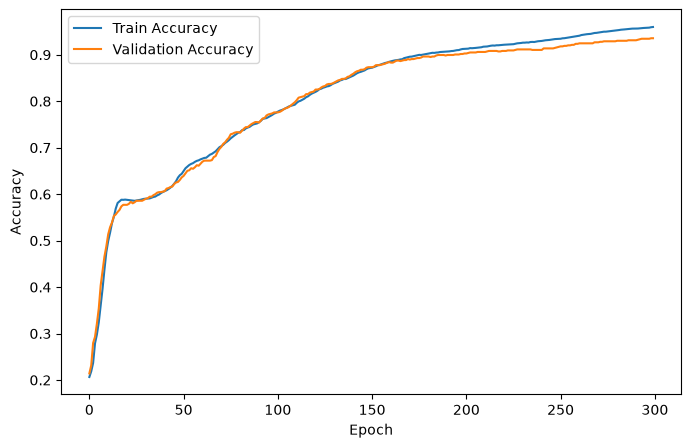

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [20]:
model.eval()

with torch.inference_mode():
    test_logits = model(X_test_tensor)
    test_loss = loss_fn(test_logits, y_test_tensor)

    test_preds = torch.argmax(test_logits, dim=1)
    test_acc = accuracy_fn(y_test_tensor, test_preds)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")    

Test Loss : 0.1961
Test Accuracy : 0.9410


In [22]:
from sklearn.metrics import classification_report

y_test_np = y_test_tensor.cpu().numpy()
test_preds_np = test_preds.cpu().numpy()

print(classification_report(
    y_test_np,
    test_preds_np,
    target_names=class_names
))

               precision    recall  f1-score   support

    Gas Giant       0.94      0.98      0.96       260
 Mini-Neptune       0.96      0.98      0.97       322
 Neptune-like       0.97      0.88      0.92        72
    Sub-Earth       1.00      0.57      0.73        35
  Super-Earth       0.90      0.96      0.93       178
Super-Jupiter       0.90      0.75      0.82        48

     accuracy                           0.94       915
    macro avg       0.94      0.85      0.89       915
 weighted avg       0.94      0.94      0.94       915



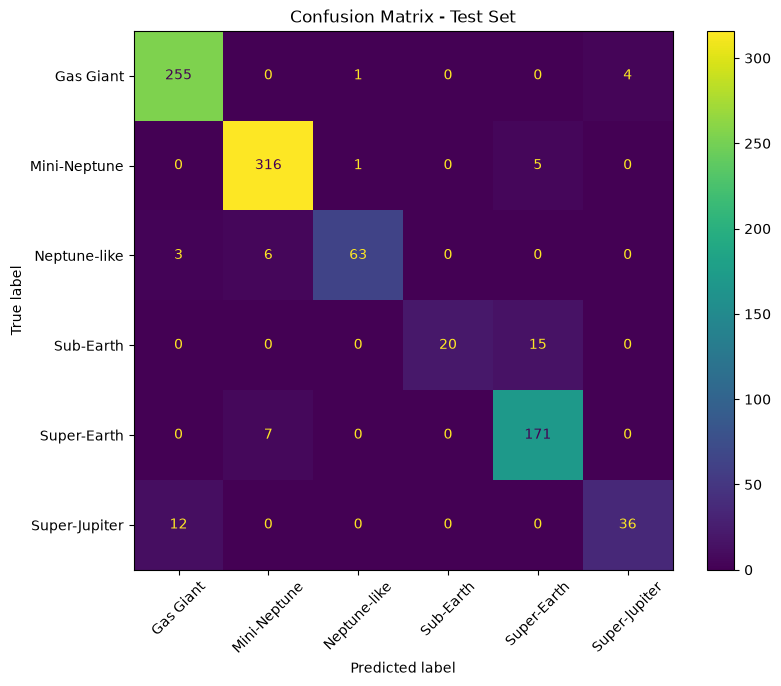

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test_np, test_preds_np)

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = class_names
)

fig, ax = plt.subplots(figsize=(9,7))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - Test Set")
plt.show()

In [26]:
artifacts_dir = PROJECT_ROOT / "artifacts"
artifacts_dir.mkdir(exist_ok=True)

model_path = artifacts_dir / "exoplanet_model.pth"

model_config = {
    "input_dim": input_dim,
    "hidden_dim": hidden_dim,
    "output_dim": output_dim,
    "class_names": class_names
}

torch.save(model.state_dict(), model_path)

with open(artifacts_dir / "model_config.json", "w", encoding="utf-8") as f:
    json.dump(model_config, f, ensure_ascii=False, indent=4)

print("Model saved to:", model_path)
print("Config saved to:", artifacts_dir / "model_config.json")

Model saved to: c:\Users\okani\OneDrive\Masaüstü\pycharm\exoplanet_intelligence\artifacts\exoplanet_model.pth
Config saved to: c:\Users\okani\OneDrive\Masaüstü\pycharm\exoplanet_intelligence\artifacts\model_config.json


In [27]:
loaded_model = ExoplanetClassifier(
    input_dim=model_config["input_dim"],
    hidden_dim=model_config["hidden_dim"],
    output_dim=model_config["output_dim"]
).to(device)

loaded_model.load_state_dict(torch.load(model_path, map_location=device))
loaded_model.eval()

with torch.inference_mode():
    loaded_logits = loaded_model(X_test_tensor)
    loaded_preds = torch.argmax(loaded_logits, dim=1)
    loaded_acc = accuracy_fn(y_test_tensor, loaded_preds)

print(f"Loaded Model Test Accuracy: {loaded_acc:.4f}")

Loaded Model Test Accuracy: 0.9410
